In [60]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
emotional_mapping = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgusted",
    "08": "surprised"
}
emotional_intensity_mapping = {
    "01": "normal",
    "02": "strong"
}
statements = {
    '01':"Kids are talking by the door",
    '02':"Dogs are sitting by the door"
}
Repetition = {
    '01':'1st repetition',
    '02':'2nd repetition'
}

In [40]:
'''
def get_emotion(filename):
    filename_ = filename.replace(".wav", "")
    filename_ = filename_.split("-")
    emotion = emotional_mapping[filename_[2]]
    intensity = emotional_intensity_mapping[filename_[3]]
    statement = statements[filename_[4]]
    repetition = Repetition[filename_[5]]
    dataframe = pd.DataFrame([[filename, emotion, intensity, statement, repetition]], columns = ['filename','emotion', 'intensity', 'statement', 'repetition'])
    return dataframe
'''

In [41]:
#get_emotion('03-01-06-01-02-01-12.wav')

,filename,emotion,intensity,statement,repetition
0,03-01-06-01-02-01-12.wav,fearful,normal,Dogs are sitting by the door,1st repetition


In [42]:
def get_emotion(filename):
    parts = filename.replace(".wav", "").split("-")
    return {
        'filename': filename,
        'emotion': emotional_mapping[parts[2]],
        'intensity': emotional_intensity_mapping[parts[3]],
        'statement': statements[parts[4]],
        'repetition': Repetition[parts[5]]
    }

In [43]:
get_emotion('03-01-06-01-02-01-12.wav')

{'filename': '03-01-06-01-02-01-12.wav',
 'emotion': 'fearful',
 'intensity': 'normal',
 'statement': 'Dogs are sitting by the door',
 'repetition': '1st repetition'}

In [51]:
DATA_PATH = "../data/"
rows = []
for root, dirs, files in os.walk(DATA_PATH):
    for file in files:
        if file.endswith('.wav'):
            full_path = os.path.join(root, file)
            row = get_emotion(file)
            row['path'] = full_path
            rows.append(row)
df = pd.DataFrame(rows)

In [52]:
df

""


In [53]:
for root, dirs, files in os.walk(DATA_PATH):
    print(f'root: {root}')
    print(f'dirs: {dirs}')
    print(f'files: {files[:3]}')
    print('---')
    break

In [54]:
print(os.path.abspath(DATA_PATH))
print(os.path.exists(DATA_PATH))

C:\Users\Arup Sarkar\Documents\data
False


In [55]:
DATA_PATH = r'C:\Users\Arup Sarkar\Documents\EmoWave\data'
print(os.path.exists(DATA_PATH))

True


In [56]:
DATA_PATH = r"C:\Users\Arup Sarkar\Documents\EmoWave\data"
rows = []
for root, dirs, files in os.walk(DATA_PATH):
    for file in files:
        if file.endswith('.wav'):
            full_path = os.path.join(root, file)
            row = get_emotion(file)
            row['path'] = full_path
            rows.append(row)
df = pd.DataFrame(rows)

In [57]:
df

,filename,emotion,intensity,statement,repetition,path
0,03-01-01-01-01-01-01.wav,neutral,normal,Kids are talking by the door,1st repetition,C:\Users\Arup Sarkar\Documents\EmoWave\data\Ac...
1,03-01-01-01-01-02-01.wav,neutral,normal,Kids are talking by the door,2nd repetition,C:\Users\Arup Sarkar\Documents\EmoWave\data\Ac...
2,03-01-01-01-02-01-01.wav,neutral,normal,Dogs are sitting by the door,1st repetition,C:\Users\Arup Sarkar\Documents\EmoWave\data\Ac...
3,03-01-01-01-02-02-01.wav,neutral,normal,Dogs are sitting by the door,2nd repetition,C:\Users\Arup Sarkar\Documents\EmoWave\data\Ac...
4,03-01-02-01-01-01-01.wav,calm,normal,Kids are talking by the door,1st repetition,C:\Users\Arup Sarkar\Documents\EmoWave\data\Ac...
...,...,...,...,...,...,...
2875,03-01-08-01-02-02-24.wav,surprised,normal,Dogs are sitting by the door,2nd repetition,C:\Users\Arup Sarkar\Documents\EmoWave\data\au...
2876,03-01-08-02-01-01-24.wav,surprised,strong,Kids are talking by the door,1st repetition,C:\Users\Arup Sarkar\Documents\EmoWave\data\au...
2877,03-01-08-02-01-02-24.wav,surprised,strong,Kids are talking by the door,2nd repetition,C:\Users\Arup Sarkar\Documents\EmoWave\data\au...
2878,03-01-08-02-02-01-24.wav,surprised,strong,Dogs are sitting by the door,1st repetition,C:\Users\Arup Sarkar\Documents\EmoWave\data\au...


<Axes: title={'center': 'Emotion Distribution'}, xlabel='emotion', ylabel='count'>

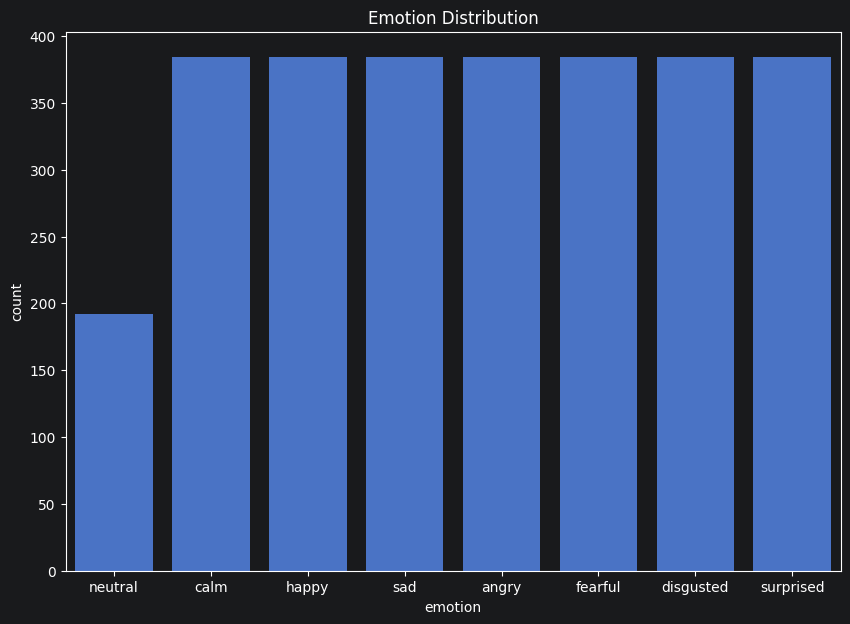

In [63]:
plt.figure(figsize=(10, 7))
plt.title("Emotion Distribution")
sns.countplot(x="emotion", data=df)

<Axes: title={'center': 'Emotional Intensity Distribution'}, xlabel='intensity', ylabel='count'>

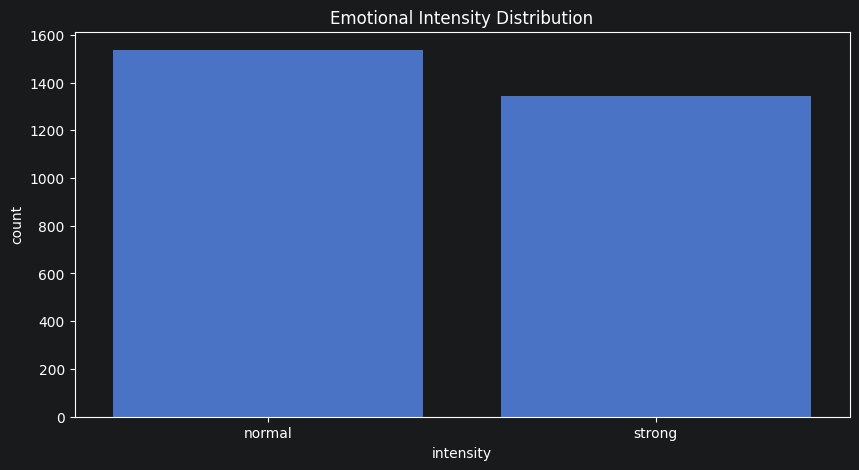

In [68]:
plt.figure(figsize=(10, 5))
plt.title("Emotional Intensity Distribution")
sns.countplot(x='intensity',data=df)

<Axes: title={'center': 'statement Distribution'}, xlabel='statement', ylabel='count'>

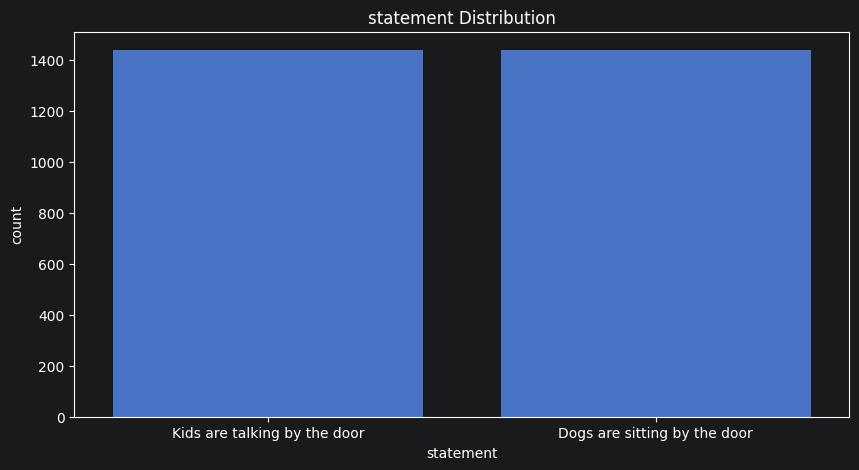

In [69]:
plt.figure(figsize=(10, 5))
plt.title("statement Distribution")
sns.countplot(x='statement',data=df)

<Axes: title={'center': 'Repetition Distribution'}, xlabel='repetition', ylabel='count'>

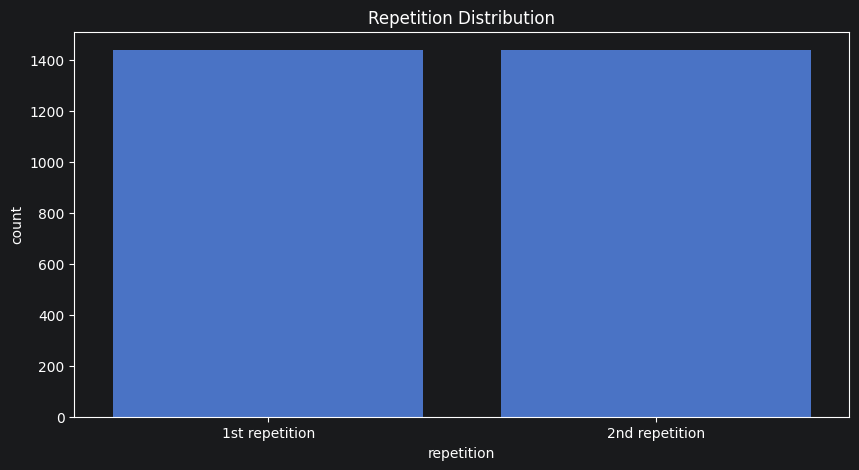

In [70]:
plt.figure(figsize=(10, 5))
plt.title("Repetition Distribution")
sns.countplot(x='repetition',data=df)